## Projektcode "Porto Seguro's Safe Driver Prediction" kompakt

Dieses Notebook bündelt die zentralen Analysen und Modellvarianten der durchgeführten Untersuchung; es ist quasi ein "best-of-code". 

Als Metriken werden ROC-AUC und der normalisierte Gini-Koeffizient verwendet.

In [2]:
# Import und setup

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml

from sklearn.model_selection import (StratifiedKFold, cross_val_score, cross_val_predict, train_test_split)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb

from sklearn.metrics import (roc_auc_score, roc_curve)

In [3]:
# Reproduzierbarkeit
RANDOM_STATE = 42
N_SPLITS = 5

# einheitliche optik
sns.set_theme(style="whitegrid", palette="muted")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [4]:
# Daten über open-ml laden

data = fetch_openml(
    data_id=42742,
    as_frame=True,
    parser="auto"
)

X = data.data.copy()
y = data.target.astype(int)

# assert, da in der open-ml Version keine column mit "id" steht
assert "id" not in X.columns

print(f"Beobachtungen: {X.shape[0]:,}")
print(f"Features:      {X.shape[1]}")

Beobachtungen: 595,212
Features:      57


In [ ]:
# Feature-Gruppen bestimmen und zusammenfassen

binary_cols = [col for col in X.columns if col.endswith("_bin")]

categorical_cols = [col for col in X.columns if col.endswith("_cat")]

numeric_cols = [col for col in X.columns if col not in binary_cols + categorical_cols]

print(f"Binäre Features:       {len(binary_cols)}")
print(f"Kategoriale Features:  {len(categorical_cols)}")
print(f"Numerische Features:   {len(numeric_cols)}")

assert (len(binary_cols)+ len(categorical_cols)+ len(numeric_cols) == X.shape[1])

Binäre Features:       17
Kategoriale Features:  14
Numerische Features:   26


In [6]:
# Datentypen vereinheitlichen

# Numerische und binäre Features als Zahlen behandeln
X[numeric_cols + binary_cols] = X[
    numeric_cols + binary_cols
].apply(pd.to_numeric, errors="coerce")

# Kategoriale features zunächst als object behandeln
# weitere Aufbereitung erfolgt innerhalb der Modelpipelines
X[categorical_cols] = X[categorical_cols].astype(object)

In [7]:
# Gemeinsame Cross-Validation

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def normalized_gini(y_true, y_score):
    """Berechnet den normalisierten Gini-Koeffizienten."""
    auc = roc_auc_score(y_true, y_score)
    return 2 * auc - 1

# Ergebnisse aller Modelle hier
results = []

# Hier Out-of-Fold-Vorhersagen gespeichert
oof_predictions = {}

## Explorative Datenanalyse / EDA

Im Folgenden werden die für die anschließende Modellierung wichtigsten Punkte des Datensatzes untersucht.

In [21]:
# DataFrame für die EDA erstellen

train = X.copy()
train["target"] = y

In [22]:
# Datenqualität und Klassenverteilung

eda_df = X.copy()
eda_df["target"] = y

n_duplicates = eda_df.duplicated().sum()

target_summary = (y.value_counts().sort_index().rename("Anzahl").to_frame())

target_summary["Anteil"] = (y.value_counts(normalize=True).sort_index())

print(f"Dubletten: {n_duplicates:,}")
display(target_summary)

Dubletten: 0


,Anzahl,Anteil
target,,
0,573518,0.9636
1,21694,0.0364


target
0    573518
1     21694
Name: count, dtype: int64
target
0   96.3550
1    3.6450
Name: proportion, dtype: float64


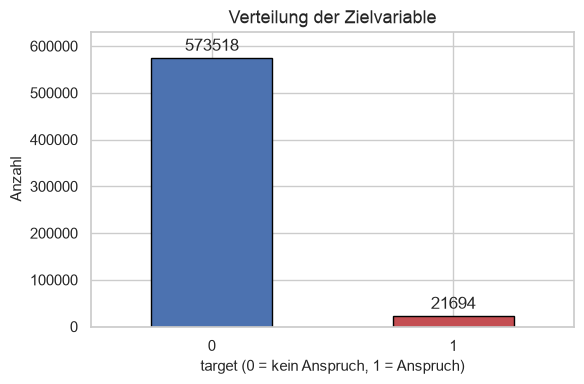

Anteil positiver Klasse: 3.6448%


In [23]:
# Targetverteilung visualisieren

counts = train["target"].value_counts().sort_index()
share = train["target"].value_counts(normalize=True).sort_index()

print(counts)
print((share * 100).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(
    kind="bar", 
    ax=ax, 
    color=["#4C72B0", "#C44E52"], 
    edgecolor="black")
# balkenbeschriftung
ax.bar_label(ax.containers[0], padding=3)
# padding für die zahlen
ax.set_ylim(0, counts.max() * 1.1)

ax.set_title("Verteilung der Zielvariable")
ax.set_xlabel("target (0 = kein Anspruch, 1 = Anspruch)")
ax.set_ylabel("Anzahl")
ax.set_xticklabels(["0", "1"], rotation=0)
plt.tight_layout()
plt.show()

print(f"Anteil positiver Klasse: {train['target'].mean():.4%}")

In [24]:
# Fehlende Werte

missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "count_missing": missing,
    "percent_missing": (missing / len(train) * 100).round(2),
})
missing_df

,count_missing,percent_missing
ps_car_03_cat,411231,69.0900
ps_car_05_cat,266551,44.7800
ps_reg_03,107772,18.1100
ps_car_14,42620,7.1600
ps_car_07_cat,11489,1.9300
ps_ind_05_cat,5809,0.9800
ps_car_09_cat,569,0.1000
ps_ind_02_cat,216,0.0400
ps_car_01_cat,107,0.0200
ps_ind_04_cat,83,0.0100


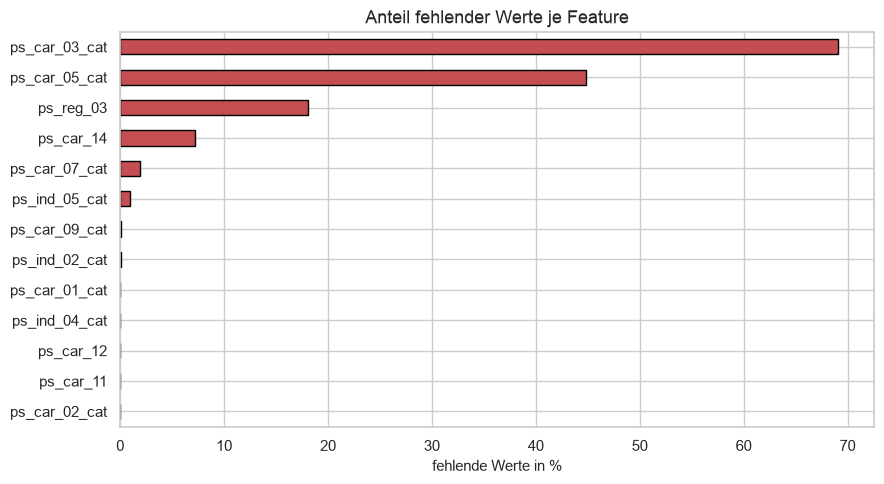

In [25]:
# Visualisierung: Anteil fehlender Werte pro Feature

fig, ax = plt.subplots(figsize=(9, 5))
missing_df["percent_missing"].sort_values().plot(kind="barh", ax=ax, color="#C44E52", edgecolor="black")
ax.set_title("Anteil fehlender Werte je Feature")
ax.set_xlabel("fehlende Werte in %")
plt.tight_layout()
plt.show()


In [26]:
# Anzahl fehlender Werte je Zeile 

n_missing_per_row = train.isna().sum(axis=1)
n_missing_per_row.describe()

count   595212.0000
mean         1.4221
std          0.9407
min          0.0000
25%          1.0000
50%          2.0000
75%          2.0000
max          8.0000
dtype: float64

In [27]:
# Hängt die Anzahl fehlender Werte je Zeile mit dem Ziel zusammen?
n_missing_per_row = train.drop(columns="target").isna().sum(axis=1)

print(n_missing_per_row.groupby(train["target"]).mean()
      .rename("mittlere Fehlwerte je Zeile"))

by_n = (pd.DataFrame({"n_miss": n_missing_per_row, "target": train["target"]})
        .groupby("n_miss")["target"].agg(target_rate="mean", n="count"))
by_n[by_n["n"] >= 1000]

target
0   1.4267
1   1.3011
Name: mittlere Fehlwerte je Zeile, dtype: float64


,target_rate,n
n_miss,,
0,0.0454,124931
1,0.0363,156295
2,0.0340,254982
3,0.0280,56042
4,0.0232,2883


In [28]:
# Absolute Korrelation numerischer Features mit dem Target

num_corr = (train[numeric_cols]
    .corrwith(train["target"])
    .abs()
    .sort_values(ascending=False))

num_corr.head(15)

ps_car_13    0.0539
ps_car_12    0.0388
ps_reg_02    0.0348
ps_reg_03    0.0338
ps_car_15    0.0277
ps_reg_01    0.0229
ps_ind_15    0.0215
ps_ind_01    0.0186
ps_car_14    0.0117
ps_ind_03    0.0084
ps_ind_14    0.0074
ps_calc_03   0.0019
ps_calc_01   0.0018
ps_calc_14   0.0014
ps_calc_02   0.0014
dtype: float64

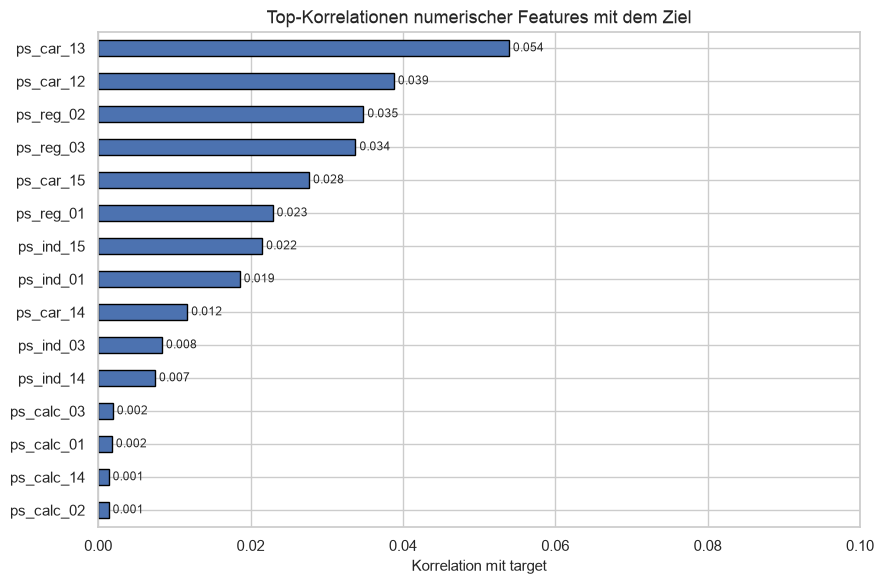

In [ ]:
# Visualisierung 

top = num_corr.head(15).sort_values()

ax = top.plot(
    kind="barh",
    figsize=(9, 6),
    color="#4C72B0",
    edgecolor="black")

ax.bar_label(
    ax.containers[0],
    fmt="%.3f",
    padding=3,
    fontsize=8.5)

ax.set_xlim(0, 0.10)
ax.set_xlabel("Korrelation mit target")
ax.set_title("Top-Korrelationen numerischer Features mit dem Ziel")

plt.tight_layout()
plt.show()

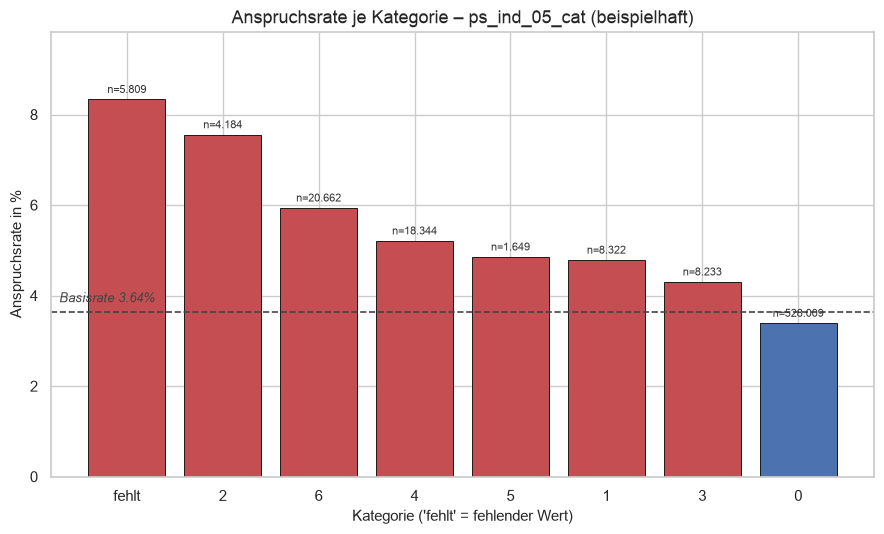

In [ ]:
### Kategoriales Feature und Target

# Anspruchsrate je Kategorie am Beispiel von ps_ind_05_cat

col = "ps_ind_05_cat"

rates = (train
    .groupby(col, observed=True, dropna=False)["target"]
    .agg(target_rate="mean", n="count")
    .sort_values("target_rate", ascending=False))

base = train["target"].mean()

# Fehlende Werte als lesbares Label darstellen
xlabels = ["fehlt" if pd.isna(value) else str(value) for value in rates.index]

# Rot: über der Basisrate, Blau: unter der Basisrate
colors = np.where(rates["target_rate"] >= base, "#C44E52", "#4C72B0")

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.bar(xlabels,
    rates["target_rate"] * 100,
    color=colors,
    edgecolor="black",
    linewidth=0.6)

ax.axhline(
    base * 100,
    linestyle="--",
    color="#444",
    linewidth=1.2)

ax.text(
    0.01,
    base * 100 + 0.15,
    f"Basisrate {base:.2%}",
    transform=ax.get_yaxis_transform(),
    ha="left",
    va="bottom",
    fontsize=9,
    color="#444",
    style="italic")

ax.bar_label(
    ax.containers[0],
    labels=[f"n={int(value):,}".replace(",", ".") for value in rates["n"]],
    padding=3,
    fontsize=8,
    color="#333")

ax.set_title("Anspruchsrate je Kategorie – ps_ind_05_cat (beispielhaft)")
ax.set_xlabel("Kategorie ('fehlt' = fehlender Wert)")
ax.set_ylabel("Anspruchsrate in %")
ax.set_ylim(0, rates["target_rate"].max() * 100 + 1.5)

plt.tight_layout()
plt.show()

In [32]:
# ps_calc-Features bestimmen

calc_cols = [col for col in X.columns if col.startswith("ps_calc_")]

calc_corr = (train[calc_cols]
    .apply(pd.to_numeric, errors="coerce")
    .corrwith(train["target"])
    .abs()
    .sort_values(ascending=False))

calc_corr.head(10)

ps_calc_03       0.0019
ps_calc_01       0.0018
ps_calc_19_bin   0.0017
ps_calc_14       0.0014
ps_calc_02       0.0014
ps_calc_12       0.0011
ps_calc_20_bin   0.0011
ps_calc_10       0.0011
ps_calc_08       0.0010
ps_calc_05       0.0008
dtype: float64

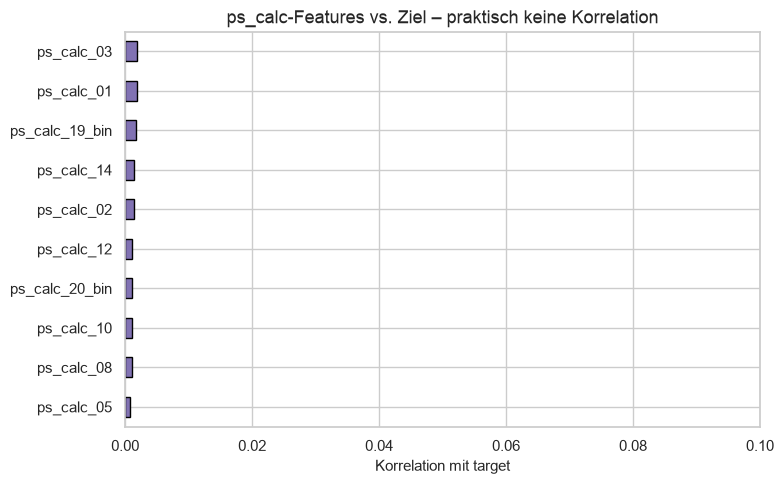

In [33]:
# Visualisierung der ps_calc-Features

ax = (calc_corr
    .head(10)
    .sort_values()
    .plot(kind="barh", figsize=(8, 5), color="#8172B3", edgecolor="black"))

ax.set_xlim(0, 0.10)
ax.set_xlabel("Korrelation mit target")
ax.set_title("ps_calc-Features vs. Ziel – praktisch keine Korrelation")

plt.tight_layout()
plt.show()

# Logistische Regression als Baseline

In [34]:
# Preprocessing für die logistische Regression

numeric_features = numeric_cols + binary_cols
categorical_features = categorical_cols

# Numerische und binäre Features:
# Median-Imputation, Missing-Indikatoren und Standardisierung
numeric_pipeline_logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())])

# Kategoriale Features:
# Fehlende Werte als eigene Kategorie und One-Hot-Encoding
categorical_pipeline_logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot",OneHotEncoder(handle_unknown="ignore", min_frequency=50))])

preprocessor_logreg = ColumnTransformer([
    ("numeric",numeric_pipeline_logreg, numeric_features),
    ("categorical", categorical_pipeline_logreg, categorical_features)])

In [35]:
# LogReg Modell definieren

logreg_model = Pipeline([("preprocessor", preprocessor_logreg),
    ("classifier", LogisticRegression(
            solver="lbfgs",
            C=1.0,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE))])

logreg_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [36]:
# Cross-Validation

logreg_oof_proba = cross_val_predict(
    estimator=logreg_model,
    X=X,
    y=y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [ ]:
# Foldweise ROC-AUC- und Gini-Werte berechnen

logreg_auc_scores = []

for _, validation_index in cv.split(X, y):
    fold_auc = roc_auc_score(
        y.iloc[validation_index],
        logreg_oof_proba[validation_index])
    logreg_auc_scores.append(fold_auc)

logreg_auc_scores = np.array(logreg_auc_scores)
logreg_gini_scores = 2 * logreg_auc_scores - 1

# Gesamte OOF-Kennzahlen
logreg_oof_auc = roc_auc_score(
    y,
    logreg_oof_proba)

logreg_oof_gini = 2 * logreg_oof_auc - 1

print("Logistische Regression – Baseline")
print("----------------------------------")
print(
    "AUC je Fold: ",
    np.round(logreg_auc_scores, 4))
print("Gini je Fold:", np.round(logreg_gini_scores, 4))

print(
    f"\nMittlere AUC:  "
    f"{logreg_auc_scores.mean():.4f} "
    f"± {logreg_auc_scores.std():.4f}")

print(
    f"Mittlerer Gini: "
    f"{logreg_gini_scores.mean():.4f} "
    f"± {logreg_gini_scores.std():.4f}")

print(f"\nOOF-AUC:  {logreg_oof_auc:.4f}")
print(f"OOF-Gini: {logreg_oof_gini:.4f}")

Logistische Regression – Baseline
----------------------------------
AUC je Fold:  [0.6338 0.6281 0.6299 0.6328 0.6254]
Gini je Fold: [0.2676 0.2561 0.2598 0.2655 0.2507]

Mittlere AUC:  0.6300 ± 0.0031
Mittlerer Gini: 0.2600 ± 0.0062

OOF-AUC:  0.6299
OOF-Gini: 0.2599


In [ ]:
# Ergebnis für den späteren Modellvergleich speichern

results.append({
    "model": "Logistische Regression",
    "variant": "Baseline",
    "auc_mean": logreg_auc_scores.mean(),
    "auc_std": logreg_auc_scores.std(),
    "gini_mean": logreg_gini_scores.mean(),
    "gini_std": logreg_gini_scores.std(),
    "oof_auc": logreg_oof_auc,
    "oof_gini": logreg_oof_gini})

oof_predictions[
    "Logistische Regression"
] = logreg_oof_proba

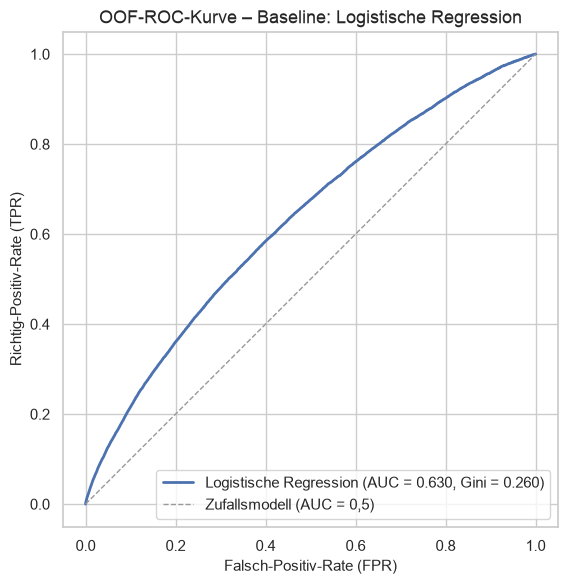

In [39]:
# 4.4 OOF-ROC-Kurve

fpr_logreg, tpr_logreg, _ = roc_curve(y, logreg_oof_proba)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(
    fpr_logreg,
    tpr_logreg,
    color="#4C72B0",
    linewidth=2,
    label=(
        "Logistische Regression "
        f"(AUC = {logreg_oof_auc:.3f}, "
        f"Gini = {logreg_oof_gini:.3f})"))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#999",
    linewidth=1,
    label="Zufallsmodell (AUC = 0,5)")

ax.set_xlabel("Falsch-Positiv-Rate (FPR)")
ax.set_ylabel("Richtig-Positiv-Rate (TPR)")
ax.set_title(
    "OOF-ROC-Kurve – Baseline: Logistische Regression")
ax.legend(loc="lower right")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# Logistische Regression mit PCA

In [40]:
# Preprocessing mit PCA

# Numerische Features:
# Imputation, Standardisierung und PCA
numeric_pipeline_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95))])

# Binäre Features:
# Imputation, aber keine Standardisierung und keine PCA
binary_pipeline_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))])

# Kategoriale Features:
# Imputation und One-Hot-Encoding
categorical_pipeline_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50))])

preprocessor_pca = ColumnTransformer([
    ("numeric_pca", numeric_pipeline_pca, numeric_cols),
    ("binary", binary_pipeline_pca, binary_cols),
    ("categorical", categorical_pipeline_pca, categorical_cols)])

In [41]:
# Logistische Regression mit PCA

logreg_pca_model = Pipeline([ ("preprocessor", preprocessor_pca),
    ("classifier", LogisticRegression(solver="lbfgs", C=1.0, class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE))])

logreg_pca_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_pca', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: flo

In [42]:
# Out-of-Fold-Vorhersagen erzeugen

logreg_pca_oof_proba = cross_val_predict(
    estimator=logreg_pca_model,
    X=X,
    y=y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [43]:
# Foldweise ROC-AUC- und Gini-Werte berechnen

logreg_pca_auc_scores = []

for _, validation_index in cv.split(X, y):
    fold_auc = roc_auc_score(
        y.iloc[validation_index],
        logreg_pca_oof_proba[validation_index])
    logreg_pca_auc_scores.append(fold_auc)

logreg_pca_auc_scores = np.array(
    logreg_pca_auc_scores)

logreg_pca_gini_scores = (
    2 * logreg_pca_auc_scores - 1)

# Gesamte OOF-Kennzahlen
logreg_pca_oof_auc = roc_auc_score(
    y,
    logreg_pca_oof_proba)

logreg_pca_oof_gini = (
    2 * logreg_pca_oof_auc - 1)

print("Logistische Regression mit PCA")
print("--------------------------------")
print(
    "AUC je Fold: ",
    np.round(logreg_pca_auc_scores, 4))
print("Gini je Fold:",
    np.round(logreg_pca_gini_scores, 4))

print(f"\nMittlere AUC:  "
    f"{logreg_pca_auc_scores.mean():.4f} "
    f"± {logreg_pca_auc_scores.std():.4f}")

print(
    f"Mittlerer Gini: "
    f"{logreg_pca_gini_scores.mean():.4f} "
    f"± {logreg_pca_gini_scores.std():.4f}")

print(f"\nOOF-AUC:  {logreg_pca_oof_auc:.4f}")
print(f"OOF-Gini: {logreg_pca_oof_gini:.4f}")

Logistische Regression mit PCA
--------------------------------
AUC je Fold:  [0.6326 0.6274 0.6295 0.6322 0.6243]
Gini je Fold: [0.2651 0.2548 0.2589 0.2644 0.2486]

Mittlere AUC:  0.6292 ± 0.0031
Mittlerer Gini: 0.2584 ± 0.0062

OOF-AUC:  0.6292
OOF-Gini: 0.2583


In [ ]:
# Ergebnis für den späteren Modellvergleich speichern

results.append({
    "model": "Logistische Regression",
    "variant": "PCA",
    "auc_mean": logreg_pca_auc_scores.mean(),
    "auc_std": logreg_pca_auc_scores.std(),
    "gini_mean": logreg_pca_gini_scores.mean(),
    "gini_std": logreg_pca_gini_scores.std(),
    "oof_auc": logreg_pca_oof_auc,
    "oof_gini": logreg_pca_oof_gini})

oof_predictions[
    "Logistische Regression mit PCA"
] = logreg_pca_oof_proba

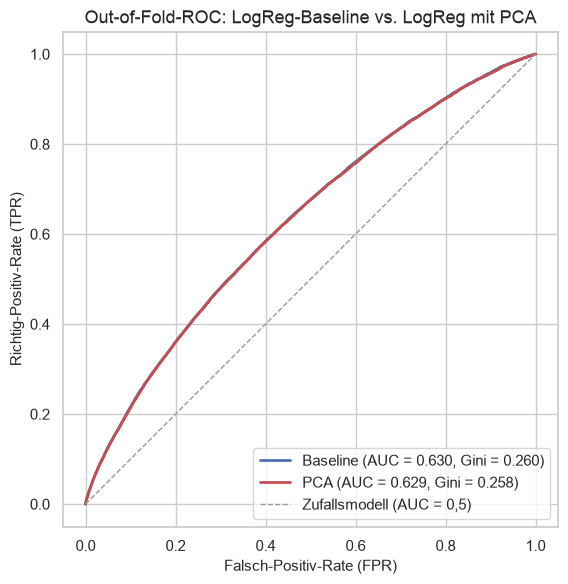

In [45]:
# OOF-ROC-Vergleich: Baseline und PCA

fpr_pca, tpr_pca, _ = roc_curve(
    y,
    logreg_pca_oof_proba)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(
    fpr_logreg,
    tpr_logreg,
    color="#4C72B0",
    linewidth=2,
    label=(
        "Baseline "
        f"(AUC = {logreg_oof_auc:.3f}, "
        f"Gini = {logreg_oof_gini:.3f})"))

ax.plot(
    fpr_pca,
    tpr_pca,
    color="#C44E52",
    linewidth=2,
    label=(
        "PCA "
        f"(AUC = {logreg_pca_oof_auc:.3f}, "
        f"Gini = {logreg_pca_oof_gini:.3f})"))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#999",
    linewidth=1,
    label="Zufallsmodell (AUC = 0,5)")

ax.set_xlabel("Falsch-Positiv-Rate (FPR)")
ax.set_ylabel("Richtig-Positiv-Rate (TPR)")
ax.set_title(
    "Out-of-Fold-ROC: LogReg-Baseline vs. LogReg mit PCA")
ax.legend(loc="lower right")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# Random Forest

Es werden zwei Random-Forest-Konfigurationen verglichen.

In [46]:
# Preprocessing für Random Forest

numeric_pipeline_rf = Pipeline([("imputer", SimpleImputer(strategy="median"))])

categorical_pipeline_rf = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot",OneHotEncoder(handle_unknown="ignore"))])

preprocessor_rf = ColumnTransformer([
    ("numeric", numeric_pipeline_rf, numeric_cols + binary_cols),
    ("categorical", categorical_pipeline_rf, categorical_cols)])

In [47]:
# Random Forest – Variante A

rf_a_model = Pipeline([
    (
        "preprocessor",
        preprocessor_rf),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=50,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE))])

rf_a_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [48]:
# Out-of-Fold-Vorhersagen für Variante A

# n_jobs=1 auf der äußeren Ebene verhindert eine
# verschachtelte Parallelisierung mit dem Random Forest.
rf_a_oof_proba = cross_val_predict(
    estimator=rf_a_model,
    X=X,
    y=y,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

In [49]:
# Foldweise und gesamte OOF-Kennzahlen

rf_a_auc_scores = []

for _, validation_index in cv.split(X, y):
    fold_auc = roc_auc_score(
        y.iloc[validation_index],
        rf_a_oof_proba[validation_index])
    rf_a_auc_scores.append(fold_auc)

rf_a_auc_scores = np.array(rf_a_auc_scores)
rf_a_gini_scores = 2 * rf_a_auc_scores - 1

rf_a_oof_auc = roc_auc_score(y, rf_a_oof_proba)
rf_a_oof_gini = 2 * rf_a_oof_auc - 1

print("Random Forest – Variante A")
print("---------------------------")
print("AUC je Fold: ", np.round(rf_a_auc_scores, 4))
print("Gini je Fold:", np.round(rf_a_gini_scores, 4))

print(
    f"\nMittlere AUC:  "
    f"{rf_a_auc_scores.mean():.4f} "
    f"± {rf_a_auc_scores.std():.4f}")

print(
    f"Mittlerer Gini: "
    f"{rf_a_gini_scores.mean():.4f} "
    f"± {rf_a_gini_scores.std():.4f}")

print(f"\nOOF-AUC:  {rf_a_oof_auc:.4f}")
print(f"OOF-Gini: {rf_a_oof_gini:.4f}")

Random Forest – Variante A
---------------------------
AUC je Fold:  [0.6396 0.6354 0.6358 0.6371 0.6306]
Gini je Fold: [0.2793 0.2709 0.2715 0.2742 0.2613]

Mittlere AUC:  0.6357 ± 0.0029
Mittlerer Gini: 0.2714 ± 0.0059

OOF-AUC:  0.6357
OOF-Gini: 0.2713


In [50]:
# Random Forest – Variante B

rf_b_model = Pipeline([
    (
        "preprocessor",
        preprocessor_rf),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=50,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE))])

rf_b_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

In [51]:
# Out-of-Fold-Vorhersagen für Variante B

rf_b_oof_proba = cross_val_predict(
    estimator=rf_b_model,
    X=X,
    y=y,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

In [52]:
# Foldweise und gesamte OOF-Kennzahlen

rf_b_auc_scores = []

for _, validation_index in cv.split(X, y):
    fold_auc = roc_auc_score(
        y.iloc[validation_index],
        rf_b_oof_proba[validation_index])
    rf_b_auc_scores.append(fold_auc)

rf_b_auc_scores = np.array(rf_b_auc_scores)
rf_b_gini_scores = 2 * rf_b_auc_scores - 1

rf_b_oof_auc = roc_auc_score(y, rf_b_oof_proba)
rf_b_oof_gini = 2 * rf_b_oof_auc - 1

print("Random Forest – Variante B")
print("---------------------------")
print("AUC je Fold: ", np.round(rf_b_auc_scores, 4))
print("Gini je Fold:", np.round(rf_b_gini_scores, 4))

print(
    f"\nMittlere AUC:  "
    f"{rf_b_auc_scores.mean():.4f} "
    f"± {rf_b_auc_scores.std():.4f}")

print(
    f"Mittlerer Gini: "
    f"{rf_b_gini_scores.mean():.4f} "
    f"± {rf_b_gini_scores.std():.4f}")

print(f"\nOOF-AUC:  {rf_b_oof_auc:.4f}")
print(f"OOF-Gini: {rf_b_oof_gini:.4f}")

Random Forest – Variante B
---------------------------
AUC je Fold:  [0.6343 0.6313 0.6324 0.634  0.6275]
Gini je Fold: [0.2686 0.2626 0.2648 0.2681 0.255 ]

Mittlere AUC:  0.6319 ± 0.0025
Mittlerer Gini: 0.2638 ± 0.0049

OOF-AUC:  0.6318
OOF-Gini: 0.2637


In [53]:
# Ergebnisse für den abschließenden Vergleich speichern

results.extend([
    {
        "model": "Random Forest",
        "variant": "Variante A",
        "auc_mean": rf_a_auc_scores.mean(),
        "auc_std": rf_a_auc_scores.std(),
        "gini_mean": rf_a_gini_scores.mean(),
        "gini_std": rf_a_gini_scores.std(),
        "oof_auc": rf_a_oof_auc,
        "oof_gini": rf_a_oof_gini
    },
    {
        "model": "Random Forest",
        "variant": "Variante B",
        "auc_mean": rf_b_auc_scores.mean(),
        "auc_std": rf_b_auc_scores.std(),
        "gini_mean": rf_b_gini_scores.mean(),
        "gini_std": rf_b_gini_scores.std(),
        "oof_auc": rf_b_oof_auc,
        "oof_gini": rf_b_oof_gini
    }
])

oof_predictions["Random Forest A"] = rf_a_oof_proba
oof_predictions["Random Forest B"] = rf_b_oof_proba

In [54]:
# Ergebnistabelle

rf_comparison = pd.DataFrame([
    {
        "Variante": "A",
        "max_depth": "unbegrenzt",
        "AUC Mittelwert": rf_a_auc_scores.mean(),
        "AUC Standardabweichung": rf_a_auc_scores.std(),
        "Gini Mittelwert": rf_a_gini_scores.mean(),
        "Gini Standardabweichung": rf_a_gini_scores.std(),
        "OOF-AUC": rf_a_oof_auc,
        "OOF-Gini": rf_a_oof_gini
    },
    {
        "Variante": "B",
        "max_depth": 12,
        "AUC Mittelwert": rf_b_auc_scores.mean(),
        "AUC Standardabweichung": rf_b_auc_scores.std(),
        "Gini Mittelwert": rf_b_gini_scores.mean(),
        "Gini Standardabweichung": rf_b_gini_scores.std(),
        "OOF-AUC": rf_b_oof_auc,
        "OOF-Gini": rf_b_oof_gini
    }
])

rf_comparison

,Variante,max_depth,AUC Mittelwert,AUC Standardabweichung,Gini Mittelwert,Gini Standardabweichung,OOF-AUC,OOF-Gini
0,A,unbegrenzt,0.6357,0.0029,0.2714,0.0059,0.6357,0.2713
1,B,12,0.6319,0.0025,0.2638,0.0049,0.6318,0.2637


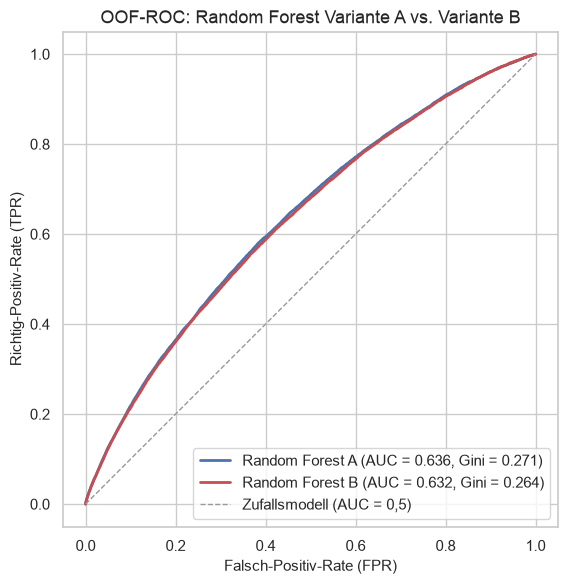

In [56]:
# OOF-ROC-Vergleich der Random-Forest-Varianten

fpr_rf_a, tpr_rf_a, _ = roc_curve(
    y,
    rf_a_oof_proba)


fpr_rf_b, tpr_rf_b, _ = roc_curve(
    y,
    rf_b_oof_proba)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(
    fpr_rf_a,
    tpr_rf_a,
    color="#4C72B0",
    linewidth=2,
    label=(
        "Random Forest A "
        f"(AUC = {rf_a_oof_auc:.3f}, "
        f"Gini = {rf_a_oof_gini:.3f})"))

ax.plot(
    fpr_rf_b,
    tpr_rf_b,
    color="#C44E52",
    linewidth=2,
    label=(
        "Random Forest B "
        f"(AUC = {rf_b_oof_auc:.3f}, "
        f"Gini = {rf_b_oof_gini:.3f})"))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#999999",
    linewidth=1,
    label="Zufallsmodell (AUC = 0,5)")

ax.set_xlabel("Falsch-Positiv-Rate (FPR)")
ax.set_ylabel("Richtig-Positiv-Rate (TPR)")
ax.set_title(
    "OOF-ROC: Random Forest Variante A vs. Variante B")
ax.legend(loc="lower right")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

# Boosting-Modelle

Für XGBoost und LightGBM werden die kategorialen Features nativ verarbeitet. Zusätzlich wird die Anzahl fehlender Werte je Beobachtung als Feature ergänzt. Beide Modelle werden in einem 2×2-Experiment mit und ohne `ps_calc` sowie mit und ohne Klassengewichtung untersucht.


In [57]:
# Daten für XGBoost und LightGBM vorbereiten

X_boost = X.copy()

for col in numeric_cols + binary_cols:
    X_boost[col] = pd.to_numeric(X_boost[col], errors="coerce")

for col in categorical_cols:
    X_boost[col] = X_boost[col].astype("category")

X_boost["ps_missing_count"] = X_boost.isna().sum(axis=1).astype("int32")

features_with_calc = list(X.columns) + ["ps_missing_count"]
features_without_calc = [
    col for col in X.columns if not col.startswith("ps_calc_")
] + ["ps_missing_count"]

boosting_experiments = {
    ("with_calc", "spw_on"): (features_with_calc, "on"),
    ("with_calc", "spw_off"): (features_with_calc, "off"),
    ("without_calc", "spw_on"): (features_without_calc, "on"),
    ("without_calc", "spw_off"): (features_without_calc, "off")
}

print(f"Mit ps_calc:  {len(features_with_calc)} Features")
print(f"Ohne ps_calc: {len(features_without_calc)} Features")

Mit ps_calc:  58 Features
Ohne ps_calc: 38 Features


In [58]:
# XGBoost-Modell

def make_xgb_model(scale_pos_weight):
    return XGBClassifier(
        n_estimators=2000, learning_rate=0.05, max_depth=4,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.5, gamma=0.0, objective="binary:logistic",
        eval_metric="auc", early_stopping_rounds=100,
        tree_method="hist", enable_categorical=True,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1
    )

In [59]:
# Cross-Validation für XGBoost

def run_xgb_cv(features, spw_mode="on"):
    X_selected = X_boost[features]
    oof = np.zeros(len(y))
    fold_ginis, best_iterations = [], []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_selected, y), start=1):
        X_train, X_valid = X_selected.iloc[train_idx], X_selected.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        X_fit, X_early, y_fit, y_early = train_test_split(
            X_train, y_train, test_size=0.2, stratify=y_train,
            random_state=RANDOM_STATE
        )

        spw = (y_fit.eq(0).sum() / y_fit.eq(1).sum()) if spw_mode == "on" else 1.0
        model = make_xgb_model(spw)
        model.fit(X_fit, y_fit, eval_set=[(X_early, y_early)], verbose=False)

        proba = model.predict_proba(X_valid)[:, 1]
        oof[valid_idx] = proba
        fold_ginis.append(normalized_gini(y_valid, proba))
        best_iterations.append(model.best_iteration)

        print(
            f"Fold {fold}: Gini={fold_ginis[-1]:.4f} | "
            f"Best iteration={model.best_iteration} | spw={spw:.1f}"
        )

    fold_ginis = np.array(fold_ginis)
    oof_gini = normalized_gini(y, oof)

    print(
        f"CV-Gini: {fold_ginis.mean():.4f} ± {fold_ginis.std():.4f} | "
        f"OOF-Gini: {oof_gini:.4f}"
    )

    return {
        "mean": fold_ginis.mean(), "std": fold_ginis.std(),
        "oof_gini": oof_gini, "fold_ginis": fold_ginis,
        "best_iterations": best_iterations, "oof": oof
    }

In [60]:
# 2x2-Experiment für XGBoost

xgb_results = {}

for (calc_tag, spw_tag), (features, spw_mode) in boosting_experiments.items():
    print(f"\n=== {calc_tag} | {spw_tag} ({len(features)} Features) ===")
    xgb_results[(calc_tag, spw_tag)] = run_xgb_cv(features, spw_mode)


=== with_calc | spw_on (58 Features) ===
Fold 1: Gini=0.2732 | Best iteration=162 | spw=26.4
Fold 2: Gini=0.2556 | Best iteration=199 | spw=26.4
Fold 3: Gini=0.2677 | Best iteration=239 | spw=26.4
Fold 4: Gini=0.2606 | Best iteration=172 | spw=26.4
Fold 5: Gini=0.2595 | Best iteration=164 | spw=26.4
CV-Gini: 0.2633 ± 0.0063 | OOF-Gini: 0.2633

=== with_calc | spw_off (58 Features) ===
Fold 1: Gini=0.2741 | Best iteration=102 | spw=1.0
Fold 2: Gini=0.2616 | Best iteration=204 | spw=1.0
Fold 3: Gini=0.2699 | Best iteration=157 | spw=1.0
Fold 4: Gini=0.2656 | Best iteration=218 | spw=1.0
Fold 5: Gini=0.2614 | Best iteration=163 | spw=1.0
CV-Gini: 0.2665 ± 0.0049 | OOF-Gini: 0.2662

=== without_calc | spw_on (38 Features) ===
Fold 1: Gini=0.2715 | Best iteration=169 | spw=26.4
Fold 2: Gini=0.2577 | Best iteration=216 | spw=26.4
Fold 3: Gini=0.2679 | Best iteration=194 | spw=26.4
Fold 4: Gini=0.2591 | Best iteration=170 | spw=26.4
Fold 5: Gini=0.2603 | Best iteration=203 | spw=26.4
CV-Gini

In [62]:
# XGBoost-Ergebnisse zusammenfassen

xgb_summary = pd.DataFrame([
    {
        "calc": calc_tag,
        "scale_pos_weight": spw_tag,
        "gini_mean": result["mean"],
        "gini_std": result["std"],
        "oof_gini": result["oof_gini"]
    }
    for (calc_tag, spw_tag), result in xgb_results.items()
]).sort_values("oof_gini", ascending=False).reset_index(drop=True)

xgb_summary.round(4)

,calc,scale_pos_weight,gini_mean,gini_std,oof_gini
0,without_calc,spw_off,0.2677,0.0055,0.2676
1,with_calc,spw_off,0.2665,0.0049,0.2662
2,with_calc,spw_on,0.2633,0.0063,0.2633
3,without_calc,spw_on,0.2633,0.0054,0.2632


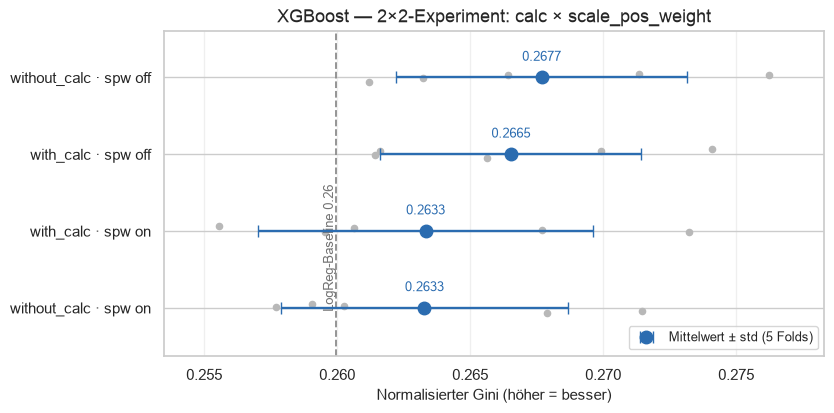

In [63]:
# XGBoost-Varianten visualisieren

rng = np.random.default_rng(RANDOM_STATE)
xgb_order = sorted(xgb_results.items(), key=lambda item: item[1]["oof_gini"], reverse=True)

labels = [f"{c} · {s.replace('spw_', 'spw ')}" for (c, s), _ in xgb_order]
means = np.array([result["mean"] for _, result in xgb_order])
stds = np.array([result["std"] for _, result in xgb_order])
folds = [result["fold_ginis"] for _, result in xgb_order]
positions = np.arange(len(xgb_order))[::-1]

fig, ax = plt.subplots(figsize=(8.5, 4.3))

ax.axvline(logreg_gini_scores.mean(), ls="--", lw=1.3, color="0.55")
ax.text(
    logreg_gini_scores.mean(), positions.min() - 0.05,
    f"LogReg-Baseline {logreg_gini_scores.mean():.2f} ",
    rotation=90, va="bottom", ha="right", color="0.45", fontsize=9)

for position, fold_values in zip(positions, folds):
    ax.scatter(
        fold_values,
        np.full(len(fold_values), position) + rng.uniform(-0.07, 0.07, len(fold_values)),
        s=20, color="0.72", zorder=2)

ax.errorbar(
    means, positions, xerr=stds, fmt="o", ms=9, color="#2b6cb0",
    capsize=4, lw=1.7, zorder=3, label="Mittelwert ± std (5 Folds)")

for position, mean in zip(positions, means):
    ax.annotate(
        f"{mean:.4f}", (mean, position), textcoords="offset points",
        xytext=(0, 12), ha="center", fontsize=9, color="#2b6cb0")

ax.set_yticks(positions)
ax.set_yticklabels(labels)
ax.set_xlabel("Normalisierter Gini (höher = besser)")
ax.set_title("XGBoost — 2×2-Experiment: calc × scale_pos_weight")
ax.margins(x=0.10, y=0.18)
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

In [64]:
# LightGBM-Modell

def make_lgb_model(scale_pos_weight):
    return LGBMClassifier(
        n_estimators=2000, learning_rate=0.05, max_depth=4,
        num_leaves=15, min_child_samples=5,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        reg_lambda=1.5, min_split_gain=0.0, objective="binary",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)

In [65]:
# Cross-Validation für LightGBM

def run_lgb_cv(features, spw_mode="on"):
    X_selected = X_boost[features]
    oof = np.zeros(len(y))
    fold_ginis, best_iterations = [], []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_selected, y), start=1):
        X_train, X_valid = X_selected.iloc[train_idx], X_selected.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        X_fit, X_early, y_fit, y_early = train_test_split(
            X_train, y_train, test_size=0.2, stratify=y_train,
            random_state=RANDOM_STATE)

        spw = (y_fit.eq(0).sum() / y_fit.eq(1).sum()) if spw_mode == "on" else 1.0
        model = make_lgb_model(spw)

        model.fit(
            X_fit, y_fit,
            eval_set=[(X_early, y_early)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])

        proba = model.predict_proba(X_valid)[:, 1]
        oof[valid_idx] = proba
        fold_ginis.append(normalized_gini(y_valid, proba))
        best_iterations.append(model.best_iteration_)

        print(
            f"Fold {fold}: Gini={fold_ginis[-1]:.4f} | "
            f"Best iteration={model.best_iteration_} | spw={spw:.1f}")

    fold_ginis = np.array(fold_ginis)
    oof_gini = normalized_gini(y, oof)

    print(
        f"CV-Gini: {fold_ginis.mean():.4f} ± {fold_ginis.std():.4f} | "
        f"OOF-Gini: {oof_gini:.4f}")

    return {
        "mean": fold_ginis.mean(), "std": fold_ginis.std(),
        "oof_gini": oof_gini, "fold_ginis": fold_ginis,
        "best_iterations": best_iterations, "oof": oof}

In [66]:
# 2x2-Experiment für LightGBM

lgb_results = {}

for (calc_tag, spw_tag), (features, spw_mode) in boosting_experiments.items():
    print(f"\n=== {calc_tag} | {spw_tag} ({len(features)} Features) ===")
    lgb_results[(calc_tag, spw_tag)] = run_lgb_cv(features, spw_mode)


=== with_calc | spw_on (58 Features) ===


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1: Gini=0.1930 | Best iteration=1 | spw=26.4


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2: Gini=0.1896 | Best iteration=1 | spw=26.4


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3: Gini=0.1783 | Best iteration=1 | spw=26.4


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4: Gini=0.1821 | Best iteration=1 | spw=26.4


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 5: Gini=0.1869 | Best iteration=1 | spw=26.4
CV-Gini: 0.1860 ± 0.0052 | OOF-Gini: 0.1876

=== with_calc | spw_off (58 Features) ===


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1: Gini=0.2739 | Best iteration=165 | spw=1.0


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2: Gini=0.2608 | Best iteration=201 | spw=1.0


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3: Gini=0.2730 | Best iteration=228 | spw=1.0


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4: Gini=0.2620 | Best iteration=164 | spw=1.0


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 5: Gini=0.2615 | Best iteration=202 | spw=1.0
CV-Gini: 0.2662 ± 0.0059 | OOF-Gini: 0.2661

=== without_calc | spw_on (38 Features) ===


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1: Gini=0.1986 | Best iteration=1 | spw=26.4


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2: Gini=0.1831 | Best iteration=1 | spw=26.4


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3: Gini=0.1883 | Best iteration=1 | spw=26.4


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4: Gini=0.1898 | Best iteration=1 | spw=26.4


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 5: Gini=0.1918 | Best iteration=1 | spw=26.4
CV-Gini: 0.1903 ± 0.0051 | OOF-Gini: 0.1927

=== without_calc | spw_off (38 Features) ===


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 1: Gini=0.2734 | Best iteration=140 | spw=1.0


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 2: Gini=0.2616 | Best iteration=296 | spw=1.0


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 3: Gini=0.2713 | Best iteration=268 | spw=1.0


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 4: Gini=0.2645 | Best iteration=219 | spw=1.0


/Users/shirin/Documents/Advanced_Data_Analytics_University_Project/.venv/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Fold 5: Gini=0.2609 | Best iteration=249 | spw=1.0
CV-Gini: 0.2663 ± 0.0051 | OOF-Gini: 0.2661


In [67]:
# LightGBM-Ergebnisse zusammenfassen

lgb_summary = pd.DataFrame([
    {
        "calc": calc_tag,
        "scale_pos_weight": spw_tag,
        "gini_mean": result["mean"],
        "gini_std": result["std"],
        "oof_gini": result["oof_gini"]
    }
    for (calc_tag, spw_tag), result in lgb_results.items()
]).sort_values("oof_gini", ascending=False).reset_index(drop=True)

lgb_summary.round(4)

,calc,scale_pos_weight,gini_mean,gini_std,oof_gini
0,with_calc,spw_off,0.2662,0.0059,0.2661
1,without_calc,spw_off,0.2663,0.0051,0.2661
2,without_calc,spw_on,0.1903,0.0051,0.1927
3,with_calc,spw_on,0.1860,0.0052,0.1876


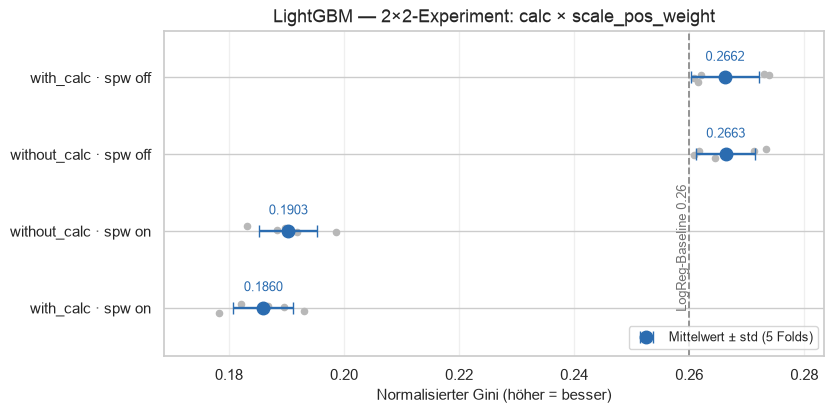

In [68]:
# LightGBM-Varianten visualisieren

rng = np.random.default_rng(RANDOM_STATE)
lgb_order = sorted(lgb_results.items(), key=lambda item: item[1]["oof_gini"], reverse=True)

labels = [f"{c} · {s.replace('spw_', 'spw ')}" for (c, s), _ in lgb_order]
means = np.array([result["mean"] for _, result in lgb_order])
stds = np.array([result["std"] for _, result in lgb_order])
folds = [result["fold_ginis"] for _, result in lgb_order]
positions = np.arange(len(lgb_order))[::-1]

fig, ax = plt.subplots(figsize=(8.5, 4.3))

ax.axvline(logreg_gini_scores.mean(), ls="--", lw=1.3, color="0.55")
ax.text(
    logreg_gini_scores.mean(), positions.min() - 0.05,
    f"LogReg-Baseline {logreg_gini_scores.mean():.2f} ",
    rotation=90, va="bottom", ha="right", color="0.45", fontsize=9)

for position, fold_values in zip(positions, folds):
    ax.scatter(
        fold_values,
        np.full(len(fold_values), position) + rng.uniform(-0.07, 0.07, len(fold_values)),
        s=20, color="0.72", zorder=2)

ax.errorbar(
    means, positions, xerr=stds, fmt="o", ms=9, color="#2b6cb0",
    capsize=4, lw=1.7, zorder=3, label="Mittelwert ± std (5 Folds)")

for position, mean in zip(positions, means):
    ax.annotate(
        f"{mean:.4f}", (mean, position), textcoords="offset points",
        xytext=(0, 12), ha="center", fontsize=9, color="#2b6cb0")

ax.set_yticks(positions)
ax.set_yticklabels(labels)
ax.set_xlabel("Normalisierter Gini (höher = besser)")
ax.set_title("LightGBM — 2×2-Experiment: calc × scale_pos_weight")
ax.margins(x=0.10, y=0.18)
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

In [69]:
# Beste Konfiguration je Boosting-Verfahren bestimmen

best_xgb_key = max(xgb_results, key=lambda key: xgb_results[key]["oof_gini"])
best_lgb_key = max(lgb_results, key=lambda key: lgb_results[key]["oof_gini"])

best_xgb = xgb_results[best_xgb_key]
best_lgb = lgb_results[best_lgb_key]

results.extend([
    {
        "model": "XGBoost",
        "variant": " · ".join(best_xgb_key),
        "auc_mean": (best_xgb["mean"] + 1) / 2,
        "auc_std": best_xgb["std"] / 2,
        "gini_mean": best_xgb["mean"],
        "gini_std": best_xgb["std"],
        "oof_auc": (best_xgb["oof_gini"] + 1) / 2,
        "oof_gini": best_xgb["oof_gini"]
    },
    {
        "model": "LightGBM",
        "variant": " · ".join(best_lgb_key),
        "auc_mean": (best_lgb["mean"] + 1) / 2,
        "auc_std": best_lgb["std"] / 2,
        "gini_mean": best_lgb["mean"],
        "gini_std": best_lgb["std"],
        "oof_auc": (best_lgb["oof_gini"] + 1) / 2,
        "oof_gini": best_lgb["oof_gini"]
    }
])

oof_predictions["XGBoost"] = best_xgb["oof"]
oof_predictions["LightGBM"] = best_lgb["oof"]

print("Beste XGBoost-Konfiguration:", best_xgb_key)
print("Beste LightGBM-Konfiguration:", best_lgb_key)

Beste XGBoost-Konfiguration: ('without_calc', 'spw_off')
Beste LightGBM-Konfiguration: ('with_calc', 'spw_off')


# Abschließender Modellvergleich

Für den abschließenden Vergleich werden die Out-of-Fold-Ergebnisse aller untersuchten Modelle gegenübergestellt. Bei XGBoost und LightGBM wird jeweils die beste Konfiguration berücksichtigt.


In [70]:
# Gemeinsame Ergebnistabelle

results_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset=["model", "variant"], keep="last")
    .sort_values("oof_gini", ascending=False)
    .reset_index(drop=True))

results_df["Modell"] = results_df["model"] + " – " + results_df["variant"]

comparison_table = results_df[[
    "Modell", "auc_mean", "auc_std",
    "gini_mean", "gini_std", "oof_auc", "oof_gini"
]].rename(columns={
    "auc_mean": "AUC Mittelwert",
    "auc_std": "AUC Standardabweichung",
    "gini_mean": "Gini Mittelwert",
    "gini_std": "Gini Standardabweichung",
    "oof_auc": "OOF-AUC",
    "oof_gini": "OOF-Gini"})

comparison_table.round(4)

,Modell,AUC Mittelwert,AUC Standardabweichung,Gini Mittelwert,Gini Standardabweichung,OOF-AUC,OOF-Gini
0,Random Forest – Variante A,0.6357,0.0029,0.2714,0.0059,0.6357,0.2713
1,XGBoost – without_calc · spw_off,0.6338,0.0027,0.2677,0.0055,0.6338,0.2676
2,LightGBM – with_calc · spw_off,0.6331,0.0030,0.2662,0.0059,0.6331,0.2661
3,Random Forest – Variante B,0.6319,0.0025,0.2638,0.0049,0.6318,0.2637
4,Logistische Regression – Baseline,0.6300,0.0031,0.2600,0.0062,0.6299,0.2599
5,Logistische Regression – PCA,0.6292,0.0031,0.2584,0.0062,0.6292,0.2583


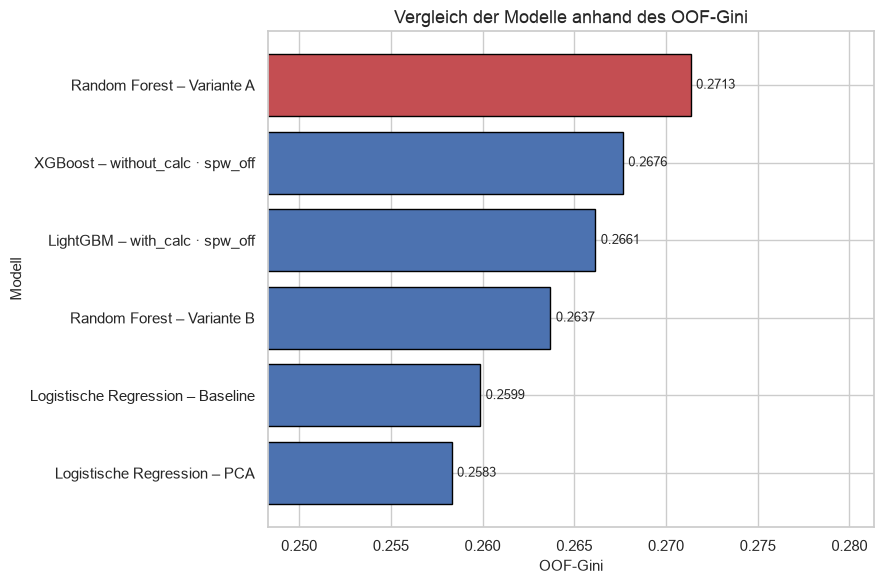

In [72]:
# OOF-Gini aller Modelle vergleichen

plot_data = results_df.sort_values("oof_gini")

fig, ax = plt.subplots(figsize=(9, 6))

colors = [
    "#C44E52" if value == plot_data["oof_gini"].max() else "#4C72B0"
    for value in plot_data["oof_gini"]]

bars = ax.barh(
    plot_data["Modell"],
    plot_data["oof_gini"],
    color=colors,
    edgecolor="black")

ax.bar_label(
    bars,
    labels=[f"{value:.4f}" for value in plot_data["oof_gini"]],
    padding=4,
    fontsize=9)

ax.set_xlabel("OOF-Gini")
ax.set_ylabel("Modell")
ax.set_title("Vergleich der Modelle anhand des OOF-Gini")
ax.set_xlim(
    plot_data["oof_gini"].min() - 0.01,
    plot_data["oof_gini"].max() + 0.01)

plt.tight_layout()
plt.show()

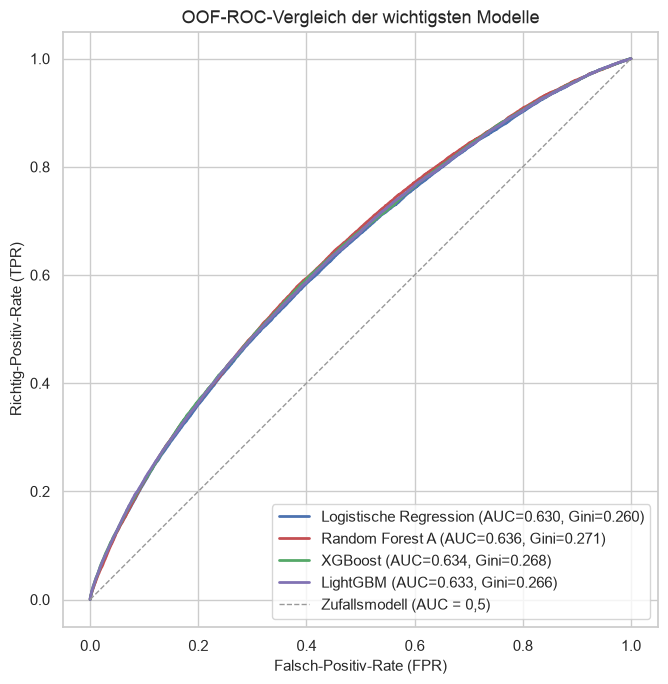

In [73]:
# OOF-ROC-Kurven der wichtigsten Modelle

roc_models = {
    "Logistische Regression": oof_predictions["Logistische Regression"],
    "Random Forest A": oof_predictions["Random Forest A"],
    "XGBoost": oof_predictions["XGBoost"],
    "LightGBM": oof_predictions["LightGBM"]}

roc_colors = {
    "Logistische Regression": "#4C72B0",
    "Random Forest A": "#C44E52",
    "XGBoost": "#55A868",
    "LightGBM": "#8172B3"}

fig, ax = plt.subplots(figsize=(7, 7))

for model_name, probabilities in roc_models.items():
    fpr, tpr, _ = roc_curve(y, probabilities)
    auc = roc_auc_score(y, probabilities)
    gini = 2 * auc - 1

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        color=roc_colors[model_name],
        label=f"{model_name} (AUC={auc:.3f}, Gini={gini:.3f})")

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#999999",
    linewidth=1,
    label="Zufallsmodell (AUC = 0,5)")

ax.set_xlabel("Falsch-Positiv-Rate (FPR)")
ax.set_ylabel("Richtig-Positiv-Rate (TPR)")
ax.set_title("OOF-ROC-Vergleich der wichtigsten Modelle")
ax.legend(loc="lower right")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [74]:
# Bestes Modell bestimmen

best_model = results_df.iloc[0]

print("Bestes Modell")
print("--------------")
print(f"Modell:             {best_model['model']}")
print(f"Variante:           {best_model['variant']}")
print(f"Mittlerer Gini:     {best_model['gini_mean']:.4f}")
print(f"Gini-Std.:          {best_model['gini_std']:.4f}")
print(f"OOF-AUC:            {best_model['oof_auc']:.4f}")
print(f"OOF-Gini:           {best_model['oof_gini']:.4f}")

Bestes Modell
--------------
Modell:             Random Forest
Variante:           Variante A
Mittlerer Gini:     0.2714
Gini-Std.:          0.0059
OOF-AUC:            0.6357
OOF-Gini:           0.2713
